## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_open_args': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 20,
                    "raise_error": false
                },
                "mode": "fixed"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "datetime",
            "step_name": "sampling",
            "test": false,
            "params": {
                "min": "2018-06-11 04:18:00",
                "max": "2018-06-11 04:20:00",
                "raise_error": false
            },
            "mode": "datetime"
        },
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "sigma": 1.0,
                "raise_error": false
            },
            "mode": "gaussian_blur"
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            },
            "mode": "sharpen"
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            },
            "mode": "contrast"
        }
    ]
}

In [6]:
pipeline.metadata

<xarray.DataArray (filename: 49)> Size: 392B
array([{'ID': 430.0, 'filename': '20180611041421.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:21'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 426737, 'image-longitude': -153.60531587, 'image-latitude': 11.25172554, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 0.937, 'image-camera-pitch-degrees': 2.287, 'heading_deg': 90.751, 'cog_deg': 188.426969021481, 'image-depth': 5203.744, 'sog_m_s': 0.0272946881279124, 'time_unix_seconds': 1528690461.02041, 'conductivity': 3.21279, 'depth_m.1': 5203.744, 'pressure_psi': 7688.29530138297, 'salinity': 34.6773, 'speed_of_sound_m_s': 1545.388, 'temperature_c': 1.5059, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:14:21', 'flag': 0, 'point': <POINT (-153.605 11.252)>},
       {'ID': 431.0, 'filename': '20180611041431.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:31'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 426916, 'image-longitude': -153.60531372, 'image-latitude': 11.25171832, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 1.326, 'image-camera-pitch-degrees': 1.993, 'heading_deg': 89.866, 'cog_deg': 221.63353933657, 'image-depth': 5203.744, 'sog_m_s': 0.0240831891575846, 'time_unix_seconds': 1528690471.02991, 'conductivity': 3.21329, 'depth_m.1': 5203.744, 'pressure_psi': 7688.29530138297, 'salinity': 34.6647, 'speed_of_sound_m_s': 1545.447, 'temperature_c': 1.5236, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:14:31', 'flag': 0, 'point': <POINT (-153.605 11.252)>},
       {'ID': 432.0, 'filename': '20180611041441.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:41'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 427094, 'image-longitude': -153.60531259, 'image-latitude': 11.2517135, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 0.577, 'image-camera-pitch-degrees': 1.59, 'heading_deg': 90.486, 'cog_deg': 226.847610265995, 'image-depth': 5203.785, 'sog_m_s': 0.0219317121994613, 'time_unix_seconds': 1528690481.01456, 'conductivity': 3.21359, 'depth_m.1': 5203.785, 'pressure_psi': 7688.35766761031, 'salinity': 34.6686, 'speed_of_sound_m_s': 1545.452, 'temperature_c': 1.5234, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:14:41', 'flag': 0, 'point': <POINT (-153.605 11.252)>},
       {'ID': 433.0, 'filename': '20180611041451.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:51'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 427274, 'image-longitude': -153.60531313, 'image-latitude': 11.25170837, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 0.841, 'image-camera-pitch-degrees': 2.262, 'heading_deg': 90.468, 'cog_deg': 232.125016348902, 'image-depth': 5203.724, 'sog_m_s': 0.0114017542509914, 'time_unix_seconds': 1528690491.06994, 'conductivity': 3.21395, 'depth_m.1': 5203.724, 'pressure_psi': 7688.26484345799, 'salinity': 34.7067, 'speed_of_sound_m_s': 1545.363, 'temperature_c': 1.4911, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 0

In [76]:
%%time
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-08-26 11:59:10 | Processing images using 16 cores


INFO:paidiverpy:Processing images using 16 cores


☁ paidiverpy ☁  |       INFO | 2025-08-26 11:59:10 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


[########################################] | 100% Completed | 102.65 ms
☁ paidiverpy ☁  |       INFO | 2025-08-26 11:59:11 | Step 0 completed


...

☁ paidiverpy ☁  |       INFO | 2025-08-26 11:59:12 | Running step 5: contrast - ColourLayer


INFO:paidiverpy:Running step 5: contrast - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-08-26 11:59:12 | Step 5 completed


INFO:paidiverpy:Step 5 completed


CPU times: user 1.67 s, sys: 43.6 ms, total: 1.71 s
Wall time: 1.68 s


Step: raw
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 0
Step: colour_correction
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 1
Step: overlapping
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 2
Step: colour_correction
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 3
Step: sharpen
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 4
Step: contrast
Image: i
Image: m
Image: a
Image: g
Image: e
Image: s
Image: _
Image: 5
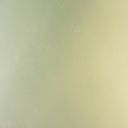
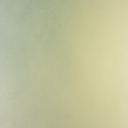
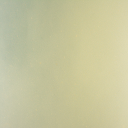
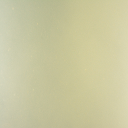
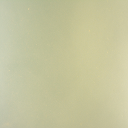
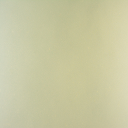
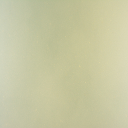
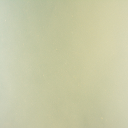
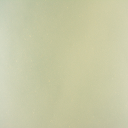
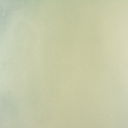
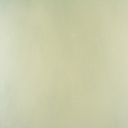
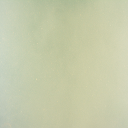
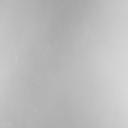
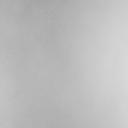
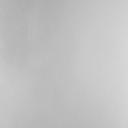
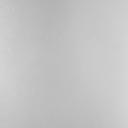
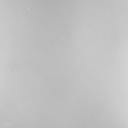
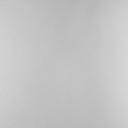
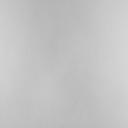
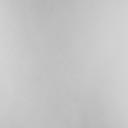
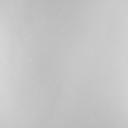
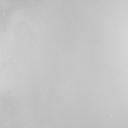
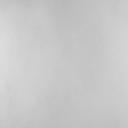
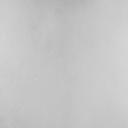
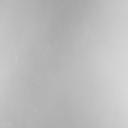
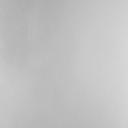
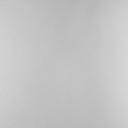
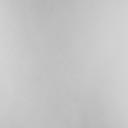
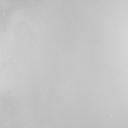
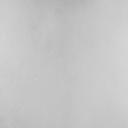
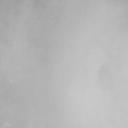
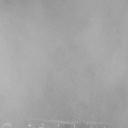
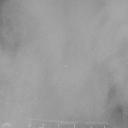
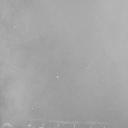
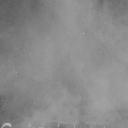
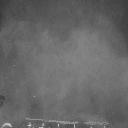
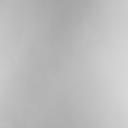
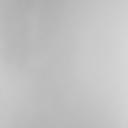
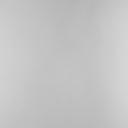
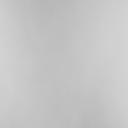
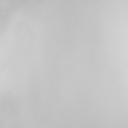
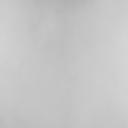
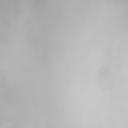
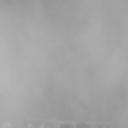
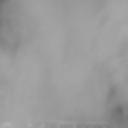
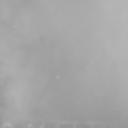
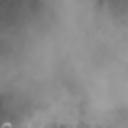
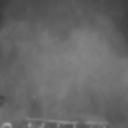
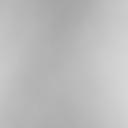
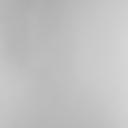
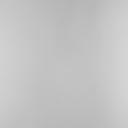
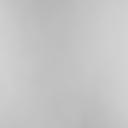
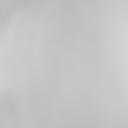
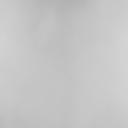
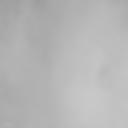
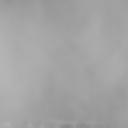
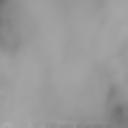
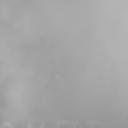
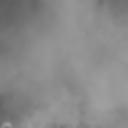
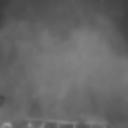
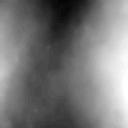
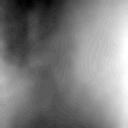
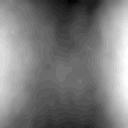
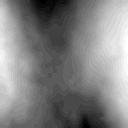
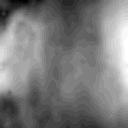
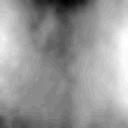
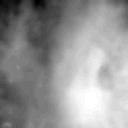
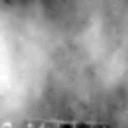
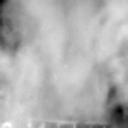
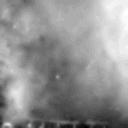
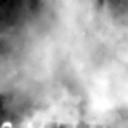
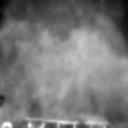

In [73]:
pipeline.images

In [156]:
pipeline.get_metadata()

<xarray.DataArray 'metadata' (filename: 20)> Size: 160B
array([{'ID': 431.0, 'filename': '20180611041431.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:31'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 426916, 'image-longitude': -153.60531372, 'image-latitude': 11.25171832, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 1.326, 'image-camera-pitch-degrees': 1.993, 'heading_deg': 89.866, 'cog_deg': 221.63353933657, 'image-depth': 5203.744, 'sog_m_s': 0.0240831891575846, 'time_unix_seconds': 1528690471.02991, 'conductivity': 3.21329, 'depth_m.1': 5203.744, 'pressure_psi': 7688.29530138297, 'salinity': 34.6647, 'speed_of_sound_m_s': 1545.447, 'temperature_c': 1.5236, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:14:31', 'flag': 0, 'point': <POINT (-153.605 11.252)>, 'num_channels': 1},
       {'ID': 432.0, 'filename': '20180611041441.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:14:41'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 427094, 'image-longitude': -153.60531259, 'image-latitude': 11.2517135, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 0.577, 'image-camera-pitch-degrees': 1.59, 'heading_deg': 90.486, 'cog_deg': 226.847610265995, 'image-depth': 5203.785, 'sog_m_s': 0.0219317121994613, 'time_unix_seconds': 1528690481.01456, 'conductivity': 3.21359, 'depth_m.1': 5203.785, 'pressure_psi': 7688.35766761031, 'salinity': 34.6686, 'speed_of_sound_m_s': 1545.452, 'temperature_c': 1.5234, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:14:41', 'flag': 0, 'point': <POINT (-153.605 11.252)>, 'num_channels': 1},
       {'ID': 434.0, 'filename': '20180611041501.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:15:01'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 427452, 'image-longitude': -153.60531414, 'image-latitude': 11.25170299, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 1.01, 'image-camera-pitch-degrees': 1.545, 'heading_deg': 89.988, 'cog_deg': 245.772254682046, 'image-depth': 5203.703, 'sog_m_s': 0.0219317121994613, 'time_unix_seconds': 1528690501.01889, 'conductivity': 3.21446, 'depth_m.1': 5203.703, 'pressure_psi': 7688.234385533, 'salinity': 34.7302, 'speed_of_sound_m_s': 1545.324, 'temperature_c': 1.4747, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'altitude_ok': 1, 'X': nan, 'phototime': '2018-06-11 04:15:01', 'flag': 0, 'point': <POINT (-153.605 11.252)>, 'num_channels': 1},
       {'ID': 439.0, 'filename': '20180611041551.png', 'XResolution': 300.0, 'YResolution': 300.0, 'ExposureTime': 0.01666666667, 'FNumber': 8.0, 'ISO': 200.0, 'image-datetime': Timestamp('2018-06-11 04:15:51'), 'MaxApertureValue': 2.82842712474619, 'WhiteBalance': 'FLASH       ', 'FocusPosition': 17.0, 'FocusDistance': 0.298538261891796, 'Unnamed: 0': 428344, 'image-longitude': -153.60532147, 'image-latitude': 11.25166737, 'image-altitude-meters': 1.5, 'image-camera-roll-degrees': 0.731, 'image-camera-pitch-degrees': 2.273, 'heading_deg': 90.602, 'cog_deg': 298.072486935853, 'image-depth': 5203.756, 'sog_m_s': 0.017, 'time_unix_seconds': 1528690551.05698, 'conductivity': 3.21481, 'depth_m.1': 5203.756, 'pressure_psi': 7688.31270591153, 'salinity': 34.759, 'speed_of_sound_m_s': 1545.263, 'temperature_c': 1.4512, 'positioning_ok': 1, 'attitude_ok': 1, 'depth_ok': 1, 'al

In [138]:
import pandas as pd
df = pd.DataFrame([[1, 2], [3, 4], [5, 6], [7, 8]], columns=["A", "B"])
df.sample(frac=0)["A"]

Series([], Name: A, dtype: int64)

In [107]:
dataset = pipeline.images.get_step(1)

<xarray.DataArray 'flag' (filename: 20)> Size: 160B
array([0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2])
Coordinates:
  * filename         (filename) <U18 1kB '20180611041851.png' ... '2018061104...
    metadata         (filename) object 160B {'ID': 457.0, 'filename': '201806...
    original_height  (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_width   (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    flag             (filename) int64 160B 0 0 0 0 0 2 2 2 2 ... 0 2 0 2 0 2 0 2

Step: raw
Image: i
Image: m
Image: a
Image: g
Image: e
Image: _
Image: 0
Step: colour_correction
Image: i
Image: m
Image: a
Image: g
Image: e
Image: _
Image: 1
Step: datetime
Image: i
Image: m
Image: a
Image: g
Image: e
Image: _
Image: 2
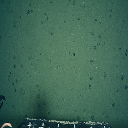
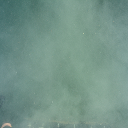
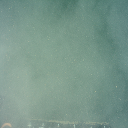
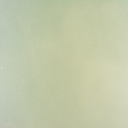
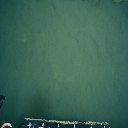
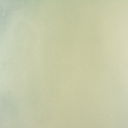
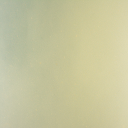
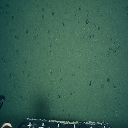
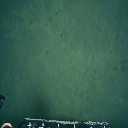
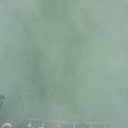
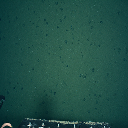
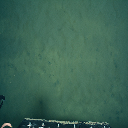
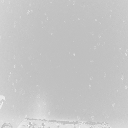
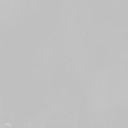
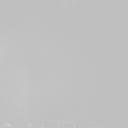
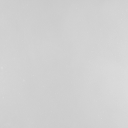
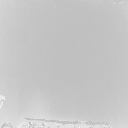
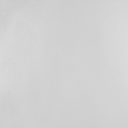
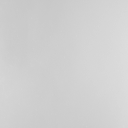
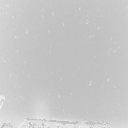
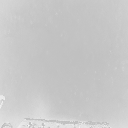
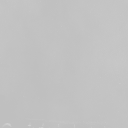
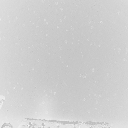
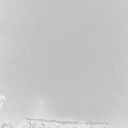
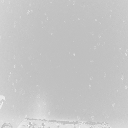
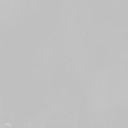
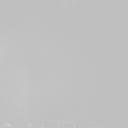
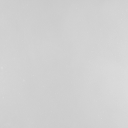
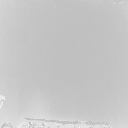
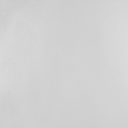
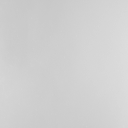
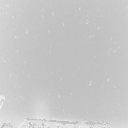
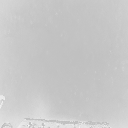
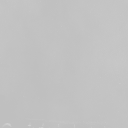
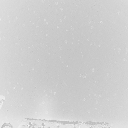
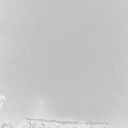

In [71]:
pipeline.images

Step: raw
Image: [[[179 189 164 255]
  [178 189 165 255]
  [180 190 168 255]
  ...
  [209 206 161 255]
  [210 205 161 255]
  [210 206 164 255]]

 [[181 190 166 255]
  [180 189 165 255]
  [179 190 169 255]
  ...
  [210 204 159 255]
  [211 206 162 255]
  [212 206 161 255]]

 [[182 190 169 255]
  [180 189 169 255]
  [183 190 168 255]
  ...
  [209 206 163 255]
  [210 204 161 255]
  [211 207 163 255]]

 ...

 [[188 190 167 255]
  [187 189 167 255]
  [193 191 167 255]
  ...
  [216 209 167 255]
  [216 210 169 255]
  [214 209 169 255]]

 [[185 188 166 255]
  [189 189 166 255]
  [190 191 167 255]
  ...
  [215 208 169 255]
  [214 209 171 255]
  [215 209 168 255]]

 [[186 189 167 255]
  [190 190 167 255]
  [192 189 167 255]
  ...
  [215 208 167 255]
  [215 208 168 255]
  [214 209 170 255]]]
Image: [[[195 203 179 255]
  [195 204 180 255]
  [195 204 179 255]
  ...
  [211 208 171 255]
  [209 209 170 255]
  [210 208 171 255]]

 [[197 204 182 255]
  [197 202 179 255]
  [195 202 180 255]
  ...
  [210 209 171 255]
  [210 208 171 255]
  [212 210 173 255]]

 [[196 204 181 255]
  [195 203 180 255]
  [198 203 181 255]
  ...
  [211 208 173 255]
  [211 208 171 255]
  [211 209 171 255]]

 ...

 [[192 195 172 255]
  [195 197 175 255]
  [198 198 173 255]
  ...
  [203 203 173 255]
  [203 202 171 255]
  [203 203 173 255]]

 [[193 195 173 255]
  [193 195 173 255]
  [197 196 174 255]
  ...
  [202 201 171 255]
  [203 202 172 255]
  [204 204 174 255]]

 [[194 196 175 255]
  [195 196 174 255]
  [196 196 172 255]
  ...
  [202 202 173 255]
  [203 202 173 255]
  [202 202 173 255]]]
Image: [[[197 207 185 255]
  [197 206 183 255]
  [195 206 183 255]
  ...
  [208 208 171 255]
  [209 209 173 255]
  [211 209 173 255]]

 [[197 208 187 255]
  [197 208 187 255]
  [196 205 184 255]
  ...
  [210 209 175 255]
  [211 209 174 255]
  [210 210 175 255]]

 [[199 208 187 255]
  [198 207 187 255]
  [199 207 187 255]
  ...
  [211 211 175 255]
  [211 209 176 255]
  [211 210 176 255]]

 ...

 [[197 199 177 255]
  [197 200 178 255]
  [199 199 177 255]
  ...
  [204 204 178 255]
  [204 205 175 255]
  [203 205 177 255]]

 [[197 198 176 255]
  [196 199 178 255]
  [198 198 177 255]
  ...
  [202 202 174 255]
  [204 204 176 255]
  [204 204 176 255]]

 [[196 198 176 255]
  [198 199 177 255]
  [199 198 176 255]
  ...
  [202 203 175 255]
  [204 203 176 255]
  [203 204 179 255]]]
Image: [[[184 197 179 255]
  [183 197 178 255]
  [181 196 178 255]
  ...
  [202 207 173 255]
  [204 207 174 255]
  [202 207 174 255]]

 [[179 195 178 255]
  [182 196 178 255]
  [183 195 179 255]
  ...
  [204 206 174 255]
  [203 207 176 255]
  [205 207 175 255]]

 [[181 195 180 255]
  [185 197 182 255]
  [185 197 182 255]
  ...
  [202 207 175 255]
  [204 207 175 255]
  [204 207 177 255]]

 ...

 [[188 194 173 255]
  [187 193 175 255]
  [191 195 174 255]
  ...
  [196 199 171 255]
  [194 197 174 255]
  [195 198 174 255]]

 [[185 192 174 255]
  [188 192 173 255]
  [192 192 175 255]
  ...
  [194 197 171 255]
  [195 198 174 255]
  [194 198 173 255]]

 [[187 193 175 255]
  [190 192 173 255]
  [190 194 172 255]
  ...
  [194 197 170 255]
  [194 196 173 255]
  [194 198 174 255]]]
Image: [[[143 165 153 255]
  [145 166 155 255]
  [149 168 158 255]
  ...
  [157 178 160 255]
  [155 177 160 255]
  [153 175 160 255]]

 [[144 165 153 255]
  [147 168 159 255]
  [146 166 156 255]
  ...
  [157 177 163 255]
  [156 177 161 255]
  [155 176 161 255]]

 [[144 166 157 255]
  [146 166 156 255]
  [147 167 156 255]
  ...
  [155 177 160 255]
  [156 177 163 255]
  [157 177 162 255]]

 ...

 [[164 176 165 255]
  [166 175 166 255]
  [174 179 167 255]
  ...
  [184 197 179 255]
  [188 198 182 255]
  [185 198 181 255]]

 [[163 171 163 255]
  [166 175 166 255]
  [173 177 165 255]
  ...
  [187 197 181 255]
  [186 197 180 255]
  [186 196 181 255]]

 [[165 174 164 255]
  [169 176 165 255]
  [175 177 165 255]
  ...
  [189 197 181 255]
  [185 197 181 255]
  [186 196 181 255]]]
Image: [[[ 87 118 112 255]
  [ 86 117 111 255]
  [ 93 122 115 255]
  ...
  [144 171 1
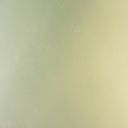
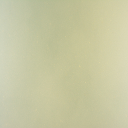
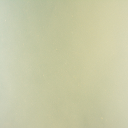
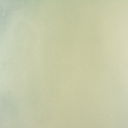
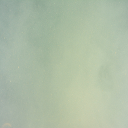
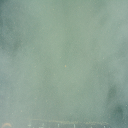
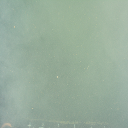
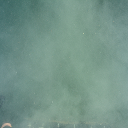
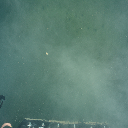
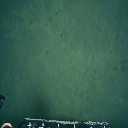
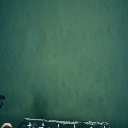
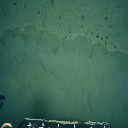
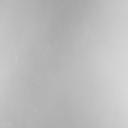
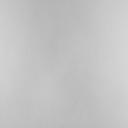
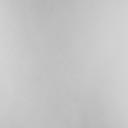
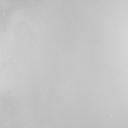
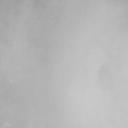
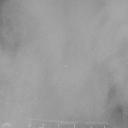
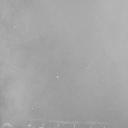
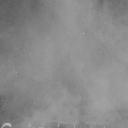
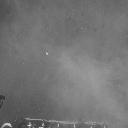
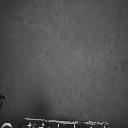
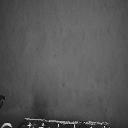
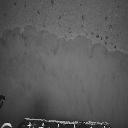
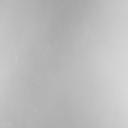
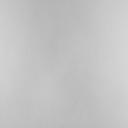
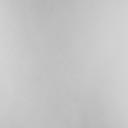
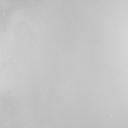
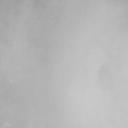
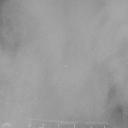
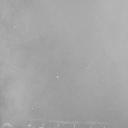
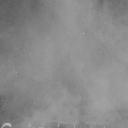
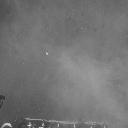
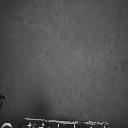
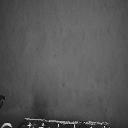
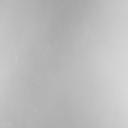
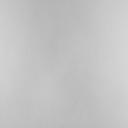
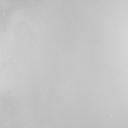
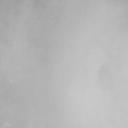
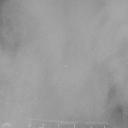
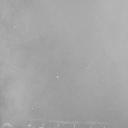
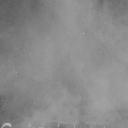
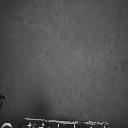
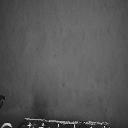
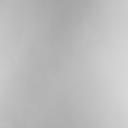
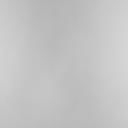
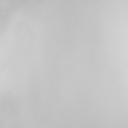
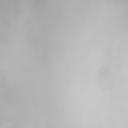
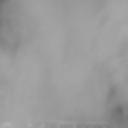
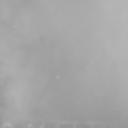
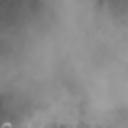
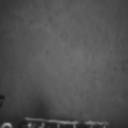
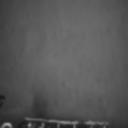
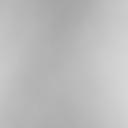
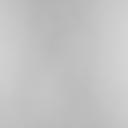
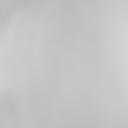
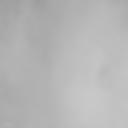
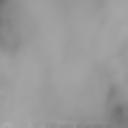
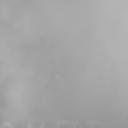
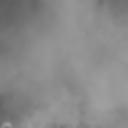
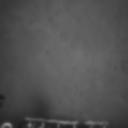
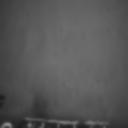
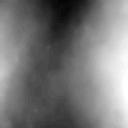
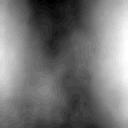
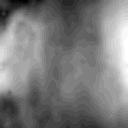
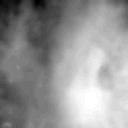
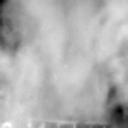
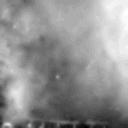
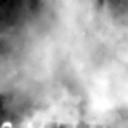
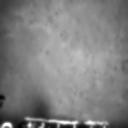
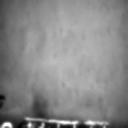

In [9]:
# See the images output
pipeline.images


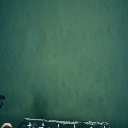
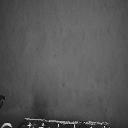
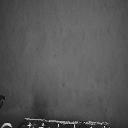

In [10]:
pipeline.images.show(image_number=10)

# Export Images to file

In [11]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Saving images from step: last
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Saving images
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Images are saved to: output
